In [42]:
import sys
import os
import pickle
import re
from pathlib import Path
from abc import ABC, abstractmethod

from Data.environment_classes import Drone, Radar, Context
from Data.synthetic_dataset_generator import DatasetMetadata, DataRequest
from Data.noise_models import AdditiveWhiteGaussianNoise

from scipy.fft import fft
import scipy
import numpy as np
from matplotlib import pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset

## Processing pipeline

In [84]:
class FileLoader(ABC):
	def __init__(self, dataset_metadata: DatasetMetadata):
		self.dataset_metadata = dataset_metadata
		pass

	@abstractmethod
	def peek_sample(self, index):
		pass

	@abstractmethod
	def load_all_data(self):
		pass


class SyntheticDataFileLoader(FileLoader):
	def __init__(self, dataset_metadata: DatasetMetadata):
		super().__init__(dataset_metadata)
		pass

	def peek_sample(self, index=1):
		md = self.dataset_metadata
		full_path = md.save_path / f"{md.filename}.{md.file_format}"
		if md.file_format == 'pkl':
			with open(full_path, "rb") as f:
				for i in range(index + 1):
					obj = pickle.load(f)
			return obj
		else:
			raise ValueError("Only pkl files are supported")

	def load_all_data(self):
		md = self.dataset_metadata
		full_path = md.save_path / f"{md.filename}.{md.file_format}"
		data = []
		with open(full_path, 'rb') as f:
			try:
				while True:
					data.append(pickle.load(f))
			except EOFError:
				pass
		return data

In [135]:
PROJECT_ROOT = Path().cwd().parent
load_path = PROJECT_ROOT / "Data" / "datasets" / "time_domain" / "training_dataset.pkl"

md = DatasetMetadata.create_from_path(load_path)
synt_dataset = SyntheticDataFileLoader(dataset_metadata=md)

In [87]:
obj = synt_dataset.peek_sample(index=6000)
obj['request']

DataRequest(request_name='label=DJI_Matrice_300_RTK', drone=Drone(name='DJI_Matrice_300_RTK', N=2, L_1=0.05, L_2=0.2665, f_rot=70), radar=Radar(λ=0.02998, f_c=9999748432.288193), context=Context(R=1185.0924324116922, V_rad=18.480347160078818, θ=1.5416963962896981, Φ_p=0.6000137166263866, A_r=5.459018212118869, snr=np.int64(25), t_start=0, t_stop=0.1, dt=0.0001), noise_model=<Data.noise_models.AdditiveWhiteGaussianNoise object at 0x0000027AFBA0A5D0>, sample_size=70)

In [88]:
class DataParser(ABC):
	def __init__(self):
		pass

	@abstractmethod
	def parse_data(self, data):
		pass

	@abstractmethod
	def extract_training_data_and_label(self, data):
		pass

In [149]:
class TimeDomainDataParser(ABC):
	def __init__(self):
		super().__init__()

	def parse_data_object(self, dataset_obj, bin_size=100):
		signal, label, misc_data = self.extract_training_data_and_label(dataset_obj)
		binned_signal = self.bin_data(signal, bin_size)
		freq_signal = self.discrete_fourier_transform(binned_signal)
		parsed_signal = self.compute_modulus(freq_signal)
		parsed_tensor = self.to_tensor(parsed_signal)
		return parsed_tensor, label, misc_data

	def extract_training_data_and_label(self, data):
		request_name = data['request'].request_name
		label = re.search(r'label=(\S+)', request_name).group(1)
		signal = data['signal']
		misc_data = data['request']
		return signal, label, misc_data

	def bin_data(self, data, bin_size=100):
		bin_array = []
		for i in range(data.shape[0]//bin_size):
			bin_array.append(np.average(data[bin_size*i:bin_size*(i+1)]))
		return np.array(bin_array)

	def discrete_fourier_transform(self, time_domain_data):
		frequency_domain_data = fft(time_domain_data)
		return frequency_domain_data

	def compute_modulus(self, data):
		modulus_data = np.absolute(data)
		return modulus_data

	def to_tensor(self, data):
		return torch.from_numpy(data)

	def apply_stft(self, time_signal, misc_data, nperseg=32, noverlap=16):
		f, t, Zreal = scipy.signal.stft(
		time_signal.real, 1 / misc_data.context.dt, window='hamming', nperseg=nperseg, noverlap=noverlap, return_onesided=True)
		Xreal = 20*np.log10(np.abs(Zreal))

		f, t, Zimag = scipy.signal.stft(
		time_signal.imag, 1 / misc_data.context.dt, window='hamming', nperseg=nperseg, noverlap=noverlap, return_onesided=True)
		Ximag = 20*np.log10(np.abs(Zimag))

		return np.stack((Xreal[1:,:], Ximag[1:,:]))

	def plot_drone_spectrogram(self, time_signal, misc_data, nperseg=32, noverlap=16):

		stft_signal = self.apply_stft(time_signal, misc_data, nperseg, noverlap)

		f_pts = stft_signal.shape[1]
		delta_t = noverlap * misc_data.context.dt
		delta_f = (1 / misc_data.context.dt) / nperseg

		fig, axs = plt.subplots(2, 1, figsize=(12, 4), sharex=True, sharey=True)
		fig.suptitle(f"Drone: {misc_data.drone.name}")

		fig.supxlabel(f"Time t (dt={delta_t:g} s) [s]")
		fig.supylabel(f"Freq. f ({f_pts} bins, df={delta_f:g} Hz) [Hz]")

		im1 = axs[0].imshow(stft_signal[0], origin='lower', aspect='auto', cmap='viridis')
		axs[0].set_title("Real")
		fig.colorbar(im1, ax=axs[0], label="Magnitude |S(t,f)|")

		im2 = axs[1].imshow(stft_signal[1], origin='lower', aspect='auto', cmap='viridis')
		axs[1].set_title("Imag.")
		fig.colorbar(im2, ax=axs[1], label="Magnitude |S(t,f)|")

		fig.tight_layout()
		plt.show()

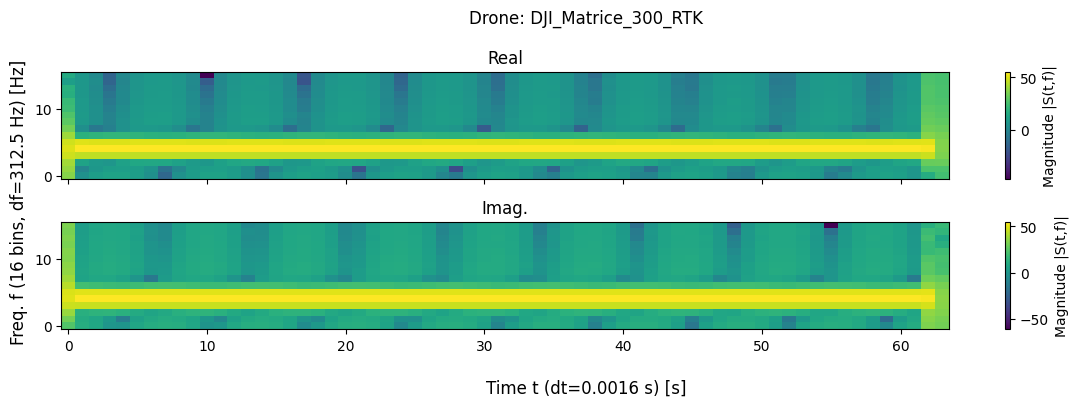

In [150]:
td_data_parser = TimeDomainDataParser()
signal, label, misc_data = td_data_parser.extract_training_data_and_label(obj)
td_data_parser.plot_drone_spectrogram(signal, misc_data, nperseg=32, noverlap=16)

In [151]:
parsed_signal, label, misc_data = td_data_parser.parse_data_object(obj)
parsed_signal, label, misc_data

(tensor([15.5519,  7.3599,  5.0009,  4.1838,  3.6280,  3.9814,  4.6683,  6.0477,
         10.2022, 54.2707], dtype=torch.float64),
 'DJI_Matrice_300_RTK',
 DataRequest(request_name='label=DJI_Matrice_300_RTK', drone=Drone(name='DJI_Matrice_300_RTK', N=2, L_1=0.05, L_2=0.2665, f_rot=70), radar=Radar(λ=0.02998, f_c=9999748432.288193), context=Context(R=1185.0924324116922, V_rad=18.480347160078818, θ=1.5416963962896981, Φ_p=0.6000137166263866, A_r=5.459018212118869, snr=np.int64(25), t_start=0, t_stop=0.1, dt=0.0001), noise_model=<Data.noise_models.AdditiveWhiteGaussianNoise object at 0x0000027AFBA0A5D0>, sample_size=70))

## Classical Machine Learning pipeline

In [158]:
class SyntheticRadarDataset(Dataset):
	def __init__(self, dataset_file_path, transform=None, target_transform=None):
		super().__init__()

		md = DatasetMetadata.create_from_path(dataset_file_path)
		loader = SyntheticDataFileLoader(dataset_metadata=md)

		raw = loader.load_all_data()
		self.metadata = raw[0]
		self._data = raw[1:]

		self.dataset_name = self.metadata['dataset_name']
		self._length = self.metadata['len']
		self.td_data_parser = TimeDomainDataParser()

		self.transform = transform
		self.target_transform = target_transform

	def __len__(self):
		return self._length

	def __getitem__(self, idx):
		# obj = self.synt_dataset.peek_sample(index=idx)
		obj = self._data[idx]
		parsed_signal, label, misc_data = td_data_parser.parse_data_object(obj)
		return parsed_signal, label

In [170]:
PROJECT_ROOT = Path().cwd().parent
training_path = PROJECT_ROOT / "Data" / "datasets" / "time_domain" / "training_dataset.pkl"
validating_path = PROJECT_ROOT / "Data" / "datasets" / "time_domain" / "validating_dataset.pkl"

training_data = SyntheticRadarDataset(training_path)
validating_data = SyntheticRadarDataset(validating_path)

In [171]:
batch_size = 32
train_dataloader = DataLoader(training_data, batch_size=batch_size, shuffle=True)
validating_dataloader = DataLoader(validating_data, batch_size=batch_size, shuffle=True)

In [172]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cpu device


In [198]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(10, 10),
            nn.ReLU(),
            nn.Linear(10, 8),
            nn.ReLU(),
            nn.Linear(8, 6),
        )

    def forward(self, x):
        logits = self.linear_relu_stack(x)
        return logits

model = NeuralNetwork().to(device)
print(model)

NeuralNetwork(
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=10, out_features=10, bias=True)
    (1): ReLU()
    (2): Linear(in_features=10, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=6, bias=True)
  )
)


In [199]:
X = torch.rand(1,10, device=device)
logits = model(X)
pred_prob = nn.Softmax(dim=1)(logits)
y_pred = pred_prob.argmax(1)
print(f"Predicted class: {y_pred}")

Predicted class: tensor([0])
